# Surrogate accuracy comparison (Appendix)

Out-of-optimisation accuracy comparison of the flexibility purchase-cost
surrogates against the **true analytical cost** (Eq. 10c), for the revised
manuscript appendix.

**Methods compared**
- **PWL** (2-D, bilinear) with 3 / 5 / 10 / 20 breakpoints — the shaping
  parameters `(a, b)` are *fixed per sample* (evaluated exactly), so the PWL
  interpolates only over `(x, y) = (flexibility, max flexibility)`. This makes
  PWL a **2-D** surrogate that is supplied the exact `(a, b)` for every point —
  i.e. it is *better-informed* than the 4-D neural networks, not handicapped.
- **UCNN** — unconstrained ReLU network (`Unconstrained model/Base_NN.keras`).
- **ICNN** — input-convex ReLU network (`FICNN model/Base_FICNN.keras`).

**Data:** 10,000 random samples over the training domain
`x in [0.098, 0.98*y], y in [0.1, 20], a in [4,8], b in [0.25,2]`.

> **SIGN CONVENTION (verify on first run):** the original accuracy script used a
> *negated* cost `TV = -lambdaCost`, and the NNs were trained on that convention.
> Here `COST_SIGN = +1` (positive cost) is used for now. If the UCNN/ICNN
> percentage errors come out near +/-200%, the NNs are in the negated convention
> and `COST_SIGN` should be set to `-1`. Small (single-digit %) errors confirm the
> positive convention is correct.


In [34]:
from tensorflow.keras.models import load_model
import pandas as pd
import os
import glob
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import random
import math
import pickle
import time
import sys 

current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

from pickle_file_operations import read_pickle, write_pickle

In [36]:
pickle_path = os.path.join(cwd, "pickle files")
optimization_input_path = os.path.join(cwd, "optimization input")

## Configuration

In [2]:
# ----- global config -----
COST_SIGN = +1          # +1 = positive cost (current); set to -1 if NN outputs are negated
NUM_VALS = 10000        # random test points (per request)
RANDOM_SEED = 1688
nPieces = [3, 5, 10, 20]  # PWL breakpoint counts for the appendix sweep

maxFlexVal = 20
minFlexVal = 0.1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## True cost and PWL machinery (from the original accuracy script)

In [3]:
def _lambdaCost(x, y, a, b):
    # Raw analytical cost kernel (Eq. 10c form). Returns a signed value.
    return round(-1 * b ** -1 * x * (math.log((y / x) - 1) - a), 3)

def lambdaCost(Flexibility, maxFlexibility, a, b, nPiece):
    lambdaCostPoints = []
    for x in Flexibility:
        for y in maxFlexibility:
            if x < y:
                lambdaCostPoints.append(_lambdaCost(x, y, a, b))
            else:
                lambdaCostPoints.append(0)
    lambdaCostPoints = np.reshape(lambdaCostPoints, (nPiece, nPiece))
    return lambdaCostPoints

def breakpointCalculator(minVal, maxVal, steps):
    profile, stepSize = np.linspace(stop=maxVal, start=minVal, num=steps, retstep=2)
    return [round(x, 3) for x in profile], round(stepSize, 3)

In [4]:
def PWL_solution(x_star, y_star, PWL_points, nPiece):
    """Bilinear (triangular) interpolation of the PWL surface at (x_star, y_star)."""
    x = PWL_points['x']
    y = PWL_points['y']
    z = PWL_points['z']
    delta_x = PWL_points['delta x']
    delta_y = PWL_points['delta y']

    # Identify the enclosing box
    if math.floor((x_star - x[0]) / delta_x) == nPiece - 1:
        x_indices = [nPiece - 2, nPiece - 1]
    else:
        x_indices = [math.floor((x_star - x[0]) / delta_x), math.floor((x_star - x[0]) / delta_x) + 1]

    if math.floor((y_star - y[0]) / delta_y) == nPiece - 1:
        y_indices = [nPiece - 2, nPiece - 1]
    else:
        y_indices = [math.floor((y_star - y[0]) / delta_y), math.floor((y_star - y[0]) / delta_y) + 1]

    # Pick the triangle within the box
    if math.atan2(y_star - y[0], x_star - x[0]) <= math.pi / 4:
        x_vals = [x[x_indices[0]], x[x_indices[1]], x[x_indices[1]]]
        y_vals = [y[y_indices[0]], y[y_indices[0]], y[y_indices[1]]]
        z_vals = np.array([z[x_indices[0]][y_indices[0]], z[x_indices[1]][y_indices[0]], z[x_indices[1]][y_indices[1]]])
    else:
        x_vals = [x[x_indices[0]], x[x_indices[0]], x[x_indices[1]]]
        y_vals = [y[y_indices[0]], y[y_indices[1]], y[y_indices[1]]]
        z_vals = np.array([z[x_indices[0]][y_indices[0]], z[x_indices[0]][y_indices[1]], z[x_indices[1]][y_indices[1]]])

    A = np.array([x_vals, y_vals, [1, 1, 1]])
    b = np.array([[x_star], [y_star], [1]])
    omega = np.linalg.inv(A) @ b
    z_star = np.transpose(omega) @ np.transpose(z_vals)
    return float(np.asarray(z_star).reshape(-1)[0])

## Load the neural networks (revised paths)

In [5]:
current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
nn_path = os.path.join(parent_directory, "NN models")

# Revised model paths:
#   UCNN -> Unconstrained model/Base_NN.keras
#   ICNN -> FICNN model/Base_FICNN.keras
ucnn_model = load_model(os.path.join(nn_path, "Unconstrained model", "Base_NN.keras"))
icnn_model = load_model(os.path.join(nn_path, "FICNN model", "Base_FICNN.keras"))

print("UCNN inputs:", ucnn_model.input_shape, " ICNN inputs:", icnn_model.input_shape)

UCNN inputs: (None, 4)  ICNN inputs: (None, 4)


In [6]:
# Min-max scaling values (identical to the original accuracy script)
min_max_vals = {'A': {'min': 4,          'max': 8},
                'B': {'min': 0.25,       'max': 2},
                'X': {'min': 0.1 * 0.98, 'max': 20 * 0.98},
                'Y': {'min': 0.1,        'max': 20},
                'Z': {'min': 0,          'max': 741.868}}

def min_max_scale(min_X, max_X, X):
    return [(x - min_X) / (max_X - min_X) for x in X]

def inv_min_max_scale(min_X, max_X, scaled_X):
    return [x * (max_X - min_X) + min_X for x in scaled_X]

## Generate 10,000 random test points

In [7]:
input_dict = {'X': [], 'Y': [], 'A': [], 'B': []}
for _ in range(NUM_VALS):
    y = round(random.uniform(0.1, 20), 3)
    x = round(random.uniform(0.1 * 0.98, 0.98 * y), 3)   # enforces x <= 0.98*y
    a = round(random.uniform(4, 8), 3)
    b = round(random.uniform(0.25, 2), 3)
    input_dict['X'].append(x)
    input_dict['Y'].append(y)
    input_dict['A'].append(a)
    input_dict['B'].append(b)

input_DF = pd.DataFrame(input_dict)
print(input_DF.describe())

                  X             Y             A             B
count  10000.000000  10000.000000  10000.000000  10000.000000
mean       4.942050     10.037005      5.999332      1.116430
std        4.307726      5.774265      1.144897      0.504224
min        0.098000      0.101000      4.000000      0.250000
25%        1.375750      4.973500      5.024750      0.683750
50%        3.697500     10.020000      6.003500      1.112000
75%        7.500000     15.078750      6.977000      1.551000
max       19.329000     19.998000      7.999000      2.000000


## PWL predictions (2-D, per-sample fixed shaping parameters)

For each test point the PWL breakpoints are rebuilt using that point's exact
`(a, b)`, then bilinearly interpolated over `(x, y)`. This is the fixed-parameter
2-D PWL referred to in the appendix text.

In [18]:
%%time
output_dict = {'True Value': []}
for nPiece in nPieces:
    output_dict[f"{nPiece} piece PWL"] = []

for row in input_DF.index:
    a = input_DF['A'].iloc[row]
    b = input_DF['B'].iloc[row]
    # True cost (sign convention controlled by COST_SIGN)
    TV = COST_SIGN * _lambdaCost(input_DF['X'].iloc[row], input_DF['Y'].iloc[row], a, b)
    output_dict['True Value'].append(TV)

    for nPiece in nPieces:
        maxFlexibilityPoints, maxFlexStepsize = breakpointCalculator(minFlexVal, maxFlexVal, nPiece)
        flexibilityPoints, flexStepsize = breakpointCalculator(minFlexVal * 0.98, maxFlexVal * 0.98, nPiece)
        # NOTE: original passes (a, -b) into lambdaCost; kept identical here.
        lambdaCostPoints = lambdaCost(flexibilityPoints, maxFlexibilityPoints, a, -b, nPiece)
        PWL_params = {'x': flexibilityPoints, 'z': lambdaCostPoints, 'y': maxFlexibilityPoints,
                      'delta x': flexStepsize, 'delta y': maxFlexStepsize}
        z_hat = PWL_solution(input_DF['X'].iloc[row], input_DF['Y'].iloc[row], PWL_params, nPiece)
        output_dict[f"{nPiece} piece PWL"].append(-z_hat)

CPU times: total: 31.8 s
Wall time: 31.8 s


## Neural network predictions

Inputs are scaled with the same min-max ranges as training; outputs are inverse
scaled back to DKK. `COST_SIGN` is applied so NN outputs share the sign
convention of `True Value`.

In [19]:
%%time
normDF = pd.DataFrame()
for column in input_DF.columns:
    normDF[column] = min_max_scale(min_max_vals[column]['min'],
                                   min_max_vals[column]['max'],
                                   input_DF[column].to_list())

ucnn_pred = inv_min_max_scale(min_max_vals['Z']['min'], min_max_vals['Z']['max'],
                              ucnn_model.predict(normDF, verbose=0))
icnn_pred = inv_min_max_scale(min_max_vals['Z']['min'], min_max_vals['Z']['max'],
                              icnn_model.predict(normDF, verbose=0))

# The NNs were (originally) trained to predict the *magnitude* under min-max on Z in [0, 741.868].
# Apply COST_SIGN so the compared quantity matches True Value's convention.
output_dict['UCNN'] = np.reshape(ucnn_pred, (NUM_VALS,))
output_dict['ICNN'] = np.reshape(icnn_pred, (NUM_VALS,))

for key in list(output_dict.keys()):
    output_dict[key] = np.reshape(np.array(output_dict[key], dtype=float), (NUM_VALS,))

CPU times: total: 1.42 s
Wall time: 1.22 s


## Assemble predictions and errors

In [20]:
pred_DF = pd.DataFrame(output_dict)
method_cols = [c for c in pred_DF.columns if c != 'True Value']
print("methods:", method_cols)
pred_DF.head()

methods: ['3 piece PWL', '5 piece PWL', '10 piece PWL', '20 piece PWL', 'UCNN', 'ICNN']


,True Value,3 piece PWL,5 piece PWL,10 piece PWL,20 piece PWL,UCNN,ICNN
0,36.043,35.841405,36.871455,36.007404,36.074902,33.350716,33.021343
1,1.363,3.115104,2.824184,1.795054,1.597205,0.722596,4.961789
2,5.010,8.341363,8.274490,5.117966,5.146467,5.250167,4.861633
3,87.936,109.993876,85.587059,87.126439,88.120128,86.678558,97.048897
4,63.503,96.004048,61.194153,64.795886,63.880277,64.068451,63.229935


In [21]:
# Absolute error and percentage error (guarded against zero-true-value).
abs_err = {}
pct_err = {}
for col in method_cols:
    diff = pred_DF[col] - pred_DF['True Value']
    abs_err[col] = diff.abs()
    with np.errstate(divide='ignore', invalid='ignore'):
        pe = 100.0 * diff / pred_DF['True Value']
    pe = pe.replace([np.inf, -np.inf], np.nan)
    pct_err[col] = pe

abs_err_DF = pd.DataFrame(abs_err)
pct_err_DF = pd.DataFrame(pct_err)

## Accuracy metrics table

In [32]:
def rmse(series):
    return float(np.sqrt(np.mean(np.square(series))))

metrics = pd.DataFrame(index=method_cols)
metrics["RMSE (DKK)"]      = [rmse(pred_DF[c] - pred_DF['True Value']) for c in method_cols]
metrics["MAE (DKK)"]       = [abs_err_DF[c].mean() for c in method_cols]
metrics["Median AE (DKK)"] = [abs_err_DF[c].median() for c in method_cols]
metrics["Max AE (DKK)"]    = [abs_err_DF[c].max() for c in method_cols]
metrics["MAPE (%)"]        = [pct_err_DF[c].abs().mean() for c in method_cols]
metrics["Median APE (%)"]  = [pct_err_DF[c].abs().median() for c in method_cols]
# fraction of points with |pct error| > pct%
pct = 5
metrics[">" + str(pct) + "% error (%)"]   = [100.0 * (pct_err_DF[c].abs() > pct).mean() for c in method_cols]
# R^2 (coefficient of determination)
def r2(col):
    ss_res = float(np.sum(np.square(pred_DF[col] - pred_DF['True Value'])))
    ss_tot = float(np.sum(np.square(pred_DF['True Value'] - pred_DF['True Value'].mean())))
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
metrics["R2"] = [r2(c) for c in method_cols]

metrics_display = metrics.copy()
metrics_display = metrics_display.round(3)
metrics_display

,RMSE (DKK),MAE (DKK),Median AE (DKK),Max AE (DKK),MAPE (%),Median APE (%),>5% error (%),R2
3 piece PWL,14.129,8.912,5.182,123.336,51.231,31.593,91.47,0.939
5 piece PWL,7.184,3.965,1.651,87.323,29.258,13.258,68.14,0.984
10 piece PWL,2.924,1.360,0.416,32.273,13.906,2.155,40.20,0.997
20 piece PWL,1.230,0.467,0.103,22.673,6.407,0.501,21.58,1.000
UCNN,1.698,1.061,0.723,37.297,87.331,3.472,39.34,0.999
ICNN,6.562,4.077,2.286,57.007,92.061,10.511,74.55,0.987


In [31]:
# LaTeX for the appendix accuracy table
print(metrics.round(3).to_latex())

\begin{tabular}{lrrrrrrrr}
\toprule
 & RMSE (DKK) & MAE (DKK) & Median AE (DKK) & Max AE (DKK) & MAPE (%) & Median APE (%) & >1% error (%) & R2 \\
\midrule
3 piece PWL & 14.129000 & 8.912000 & 5.182000 & 123.336000 & 51.231000 & 31.593000 & 98.060000 & 0.939000 \\
5 piece PWL & 7.184000 & 3.965000 & 1.651000 & 87.323000 & 29.258000 & 13.258000 & 89.850000 & 0.984000 \\
10 piece PWL & 2.924000 & 1.360000 & 0.416000 & 32.273000 & 13.906000 & 2.155000 & 63.800000 & 0.997000 \\
20 piece PWL & 1.230000 & 0.467000 & 0.103000 & 22.673000 & 6.407000 & 0.501000 & 38.750000 & 1.000000 \\
UCNN & 1.698000 & 1.061000 & 0.723000 & 37.297000 & 87.331000 & 3.472000 & 81.200000 & 0.999000 \\
ICNN & 6.562000 & 4.077000 & 2.286000 & 57.007000 & 92.061000 & 10.511000 & 94.560000 & 0.987000 \\
\bottomrule
\end{tabular}



## Figures

### (a) Percentage-error distribution (headline figure)

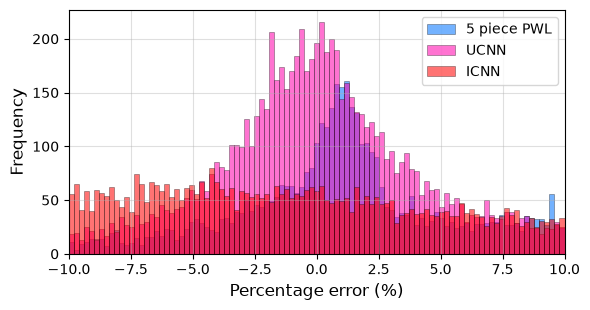

In [24]:
# Overlaid histograms of percentage error for the key methods.
makedir_target = os.path.join(parent_directory, "images_revised")
if not os.path.exists(makedir_target):
    os.mkdir(makedir_target)

focus = [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]
cmap = matplotlib.colormaps['hsv']
color_map = {"5 piece PWL": cmap(0.60), "UCNN": cmap(0.90), "ICNN": cmap(0.0)}
bins = np.linspace(-10, 10, 100)

fig, ax = plt.subplots(figsize=(6, 3.2))
for col in focus:
    ax.hist(pct_err_DF[col].dropna(), bins=bins, alpha=0.55, label=col,
            color=color_map.get(col, None), edgecolor="black", linewidth=0.4)
ax.set_xlabel("Percentage error (%)", fontsize="large")
ax.set_ylabel("Frequency", fontsize="large")
ax.set_xlim(-10, 10)
ax.legend(fontsize="medium")
ax.grid(alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_pct_error_hist.pdf"), bbox_inches="tight")
plt.show()

### (b) RMSE bar chart across all methods (incl. PWL sweep)

C:\Users\a1842184\AppData\Local\Temp\ipykernel_13560\3505987788.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order, rotation=30, ha="right", fontsize="medium")


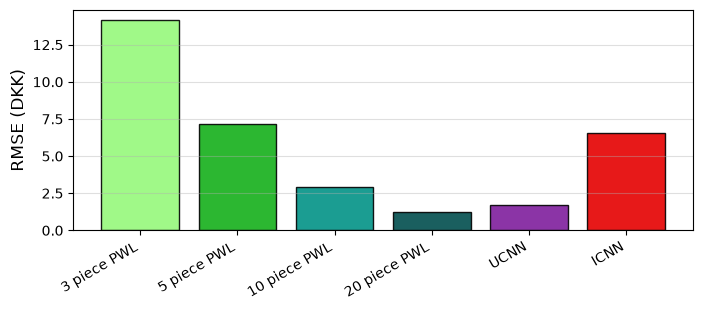

In [25]:
fig, ax = plt.subplots(figsize=(7, 3.2))
order = [c for c in ["3 piece PWL", "5 piece PWL", "10 piece PWL", "20 piece PWL", "UCNN", "ICNN"] if c in method_cols]
vals = [metrics.loc[m, "RMSE (DKK)"] for m in order]
barcolors = ["xkcd:light green", "xkcd:green", "xkcd:teal", "xkcd:dark teal", "xkcd:purple", "xkcd:red"][:len(order)]
ax.bar(order, vals, color=barcolors, edgecolor="black", alpha=0.9)
ax.set_ylabel("RMSE (DKK)", fontsize="large")
ax.set_xticklabels(order, rotation=30, ha="right", fontsize="medium")
ax.grid(axis="y", alpha=0.4, zorder=0)
plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_rmse_bar.pdf"), bbox_inches="tight")
plt.show()

### (c) Predicted vs true scatter (UCNN, ICNN, 5-piece PWL)

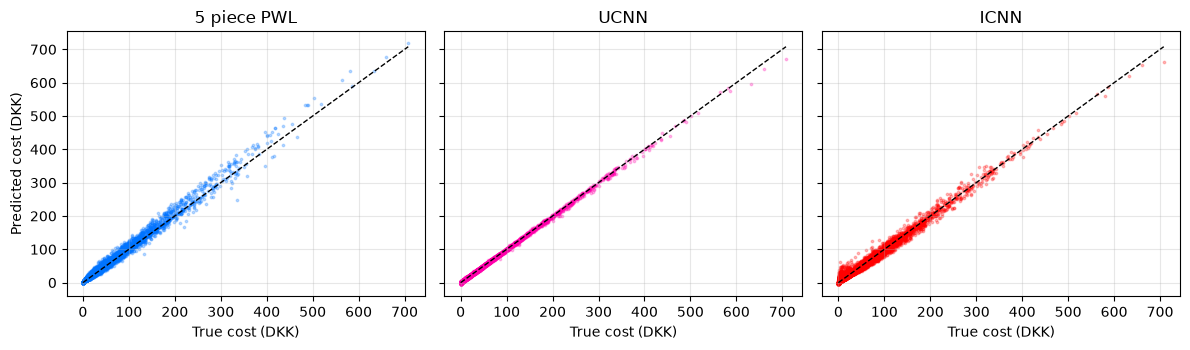

In [26]:
focus_scatter = [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]
fig, axes = plt.subplots(1, len(focus_scatter), figsize=(4 * len(focus_scatter), 3.6), sharex=True, sharey=True)
if len(focus_scatter) == 1:
    axes = [axes]
lims = [pred_DF['True Value'].min(), pred_DF['True Value'].max()]
for axc, col in zip(axes, focus_scatter):
    axc.scatter(pred_DF['True Value'], pred_DF[col], s=3, alpha=0.25,
                color=color_map.get(col, "xkcd:grey"))
    axc.plot(lims, lims, "k--", linewidth=1)
    axc.set_title(col, fontsize="large")
    axc.set_xlabel("True cost (DKK)", fontsize="medium")
    axc.grid(alpha=0.3)
axes[0].set_ylabel("Predicted cost (DKK)", fontsize="medium")
plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_scatter.pdf"), bbox_inches="tight")
plt.show()

### (d) Error vs flexibility ratio (where does each surrogate struggle?)

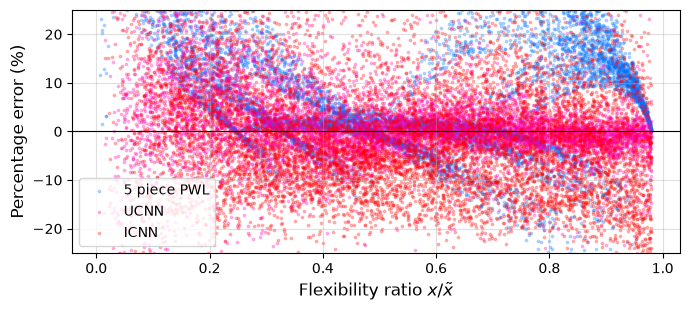

In [27]:
# Percentage error vs (x / y) ratio, which controls proximity to the singularity.
ratio = (input_DF['X'] / input_DF['Y']).values
fig, ax = plt.subplots(figsize=(7, 3.2))
for col in [c for c in ["5 piece PWL", "UCNN", "ICNN"] if c in method_cols]:
    ax.scatter(ratio, pct_err_DF[col], s=3, alpha=0.25, label=col, color=color_map.get(col, None))
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel(r"Flexibility ratio $x/\tilde{x}$", fontsize="large")
ax.set_ylabel("Percentage error (%)", fontsize="large")
ax.set_ylim(-25, 25)
ax.legend(fontsize="medium")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(makedir_target, "appendix_accuracy_error_vs_ratio.pdf"), bbox_inches="tight")
plt.show()

## Notes for the appendix write-up

- **PWL is 2-D and better-informed:** for every test point the PWL breakpoints are
  rebuilt with that point's exact `(a, b)`, so PWL interpolates only over `(x, y)`
  while receiving the true shaping parameters. The 4-D UCNN/ICNN must instead learn
  the `(a, b)` dependence from data. Any PWL RMSE advantage therefore reflects this
  information asymmetry, not an intrinsic superiority of the embedding — this is the
  point to make when contrasting with the in-optimisation results.
- **Sign convention:** confirm `COST_SIGN`. If UCNN/ICNN errors are ~±200%, set
  `COST_SIGN = -1` (NNs trained on the negated cost) and re-run.
- **Metrics table** gives RMSE / MAE / median AE / max AE / MAPE / >5% fraction / R²
  per method. RMSE (DKK) is the headline; the >5% fraction mirrors the original
  script's accuracy criterion.
- **Figures saved to `images_revised/`:** percentage-error histogram, RMSE bar,
  predicted-vs-true scatter, and error-vs-ratio diagnostic.
- 10,000 points is a placeholder ("for now"); bump `NUM_VALS` for the final run.


In [37]:
# --- Consistency check: does our PWL construction match the stored breakpoints? ---
# Load the stored prosumer-responsiveness PWL data and compare one (nPiece, hour)
# breakpoint set against a freshly built one, to confirm identical construction.
import numpy as np

stored = read_pickle(os.path.join(pickle_path, "prosumRespMultiPWL.pickle"))   # same file used by Generate_inputs
nPiece_chk = 5
hour_chk = 0
a_chk, negb_chk = stored[nPiece_chk][hour_chk]['(a, b)']   # note: stored as (a, -b)

# Rebuild with our accuracy-notebook machinery
maxF, _ = breakpointCalculator(minFlexVal, maxFlexVal, nPiece_chk)
flexF, _ = breakpointCalculator(minFlexVal * 0.98, maxFlexVal * 0.98, nPiece_chk)
z_rebuilt = lambdaCost(flexF, maxF, a_chk, negb_chk, nPiece_chk)   # a, -b passed straight through

print("flex breakpoints match:",
      np.allclose(flexF, stored[nPiece_chk][hour_chk]['Flex breakpoint']))
print("max-flex breakpoints match:",
      np.allclose(maxF, stored[nPiece_chk][hour_chk]['max Flex breakpoint']))
print("cost breakpoints match:",
      np.allclose(z_rebuilt, stored[nPiece_chk][hour_chk]['Flex Cost breakpoint']))

flex breakpoints match: True
max-flex breakpoints match: True
cost breakpoints match: False


In [38]:
# Diagnose the cost mismatch precisely
a_chk, negb_chk = stored[nPiece_chk][hour_chk]['(a, b)']
print("stored (a, b) tuple:", (a_chk, negb_chk))   # is 2nd element negative or positive?

z_stored = np.array(stored[nPiece_chk][hour_chk]['Flex Cost breakpoint'])

# Try BOTH sign conventions
z_negb = lambdaCost(flexF, maxF, a_chk, negb_chk, nPiece_chk)          # pass as-stored
z_posb = lambdaCost(flexF, maxF, a_chk, -negb_chk, nPiece_chk)         # flip it

print("matches as-stored (a, -b):", np.allclose(z_negb, z_stored))
print("matches flipped   (a, +b):", np.allclose(z_posb, z_stored))
print("stored[0,:3]  :", z_stored.reshape(nPiece_chk, nPiece_chk)[0, :3])
print("as-stored[0,:3]:", np.array(z_negb).reshape(nPiece_chk, nPiece_chk)[0, :3])
print("flipped[0,:3] :", np.array(z_posb).reshape(nPiece_chk, nPiece_chk)[0, :3])

stored (a, b) tuple: (7, -0.28849178318881075)
matches as-stored (a, -b): False
matches flipped   (a, +b): True
stored[0,:3]  : [3.7   1.044 0.808]
as-stored[0,:3]: [-3.7   -1.044 -0.808]
flipped[0,:3] : [3.7   1.044 0.808]
